## Data File

Downloaded the roman empire version used in the Yandex Research from https://www.kaggle.com/datasets/nbroad/wiki-20220301-en/data
Found the article from 26 parquet file by scanning them and extracting the exact document. 

In [8]:
#with open("../data/roman_empire_wikipedia_2022.txt", "r", encoding="utf-8") as f:
with open("../data/roman_empire_wikipedia_20220301.txt", "r", encoding="utf-8") as f:
    roman_empire = f.read()

## Roman - Empire Graph 

https://arxiv.org/pdf/2302.11640

This dataset is based on the Roman Empire article from English Wikipedia, which was selected since it is one of the longest articles on Wikipedia. The text was retrieved from the English Wikipedia 2022.03.01 dump from Lhoest et al. (2021). Each node in the graph corresponds to one (non-unique) word in the text. Thus, the number of nodes in the graph is equal to the article’s length. Two words are connected with an edge if at least one of the following two conditions holds:
either these words follow each other in the text, or these words are connected in the dependency tree of the sentence (one word depends on the other). Thus, the graph is a chain graph with additional shortcut edges corresponding to syntactic dependencies between words. 

In [9]:
import spacy
import networkx as nx
import torch
import numpy as np
import pandas as pd


In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"


In [11]:
import spacy
import networkx as nx

nlp = spacy.load("en_core_web_md")
doc = nlp(roman_empire)

# Use a Graph (undirected) to ensure A-B is only one edge
G = nx.Graph() 

#Not punctuation and space, only words
valid_tokens = [t for t in doc if not t.is_punct and not t.is_space]
token_lookup = {t.i: j for j, t in enumerate(valid_tokens)}

for j, token in enumerate(valid_tokens):
    G.add_node(j)
    
    # Sequential connection (The Chain)
    if j < len(valid_tokens) - 1:
        G.add_edge(j, j + 1)
    
    #Syntactic Dependency (The Shortcuts)
    if token.head.i in token_lookup:
        target_j = token_lookup[token.head.i]
        if target_j != j:
            # .add_edge in nx.Graph() automatically handles "at least one"
            # If the edge already exists from the chain logic, it won't add a duplicate
            G.add_edge(j, target_j)

print(f"Graph: {G.number_of_nodes()} nodes and {G.number_of_edges()} edges.")


Graph: 22600 nodes and 32684 edges.


In [12]:
print(f"Length of valid tokens is {len(valid_tokens)}")

Length of valid tokens is 22600


## Group by sentences

In [13]:
sentences = []
for sent in doc.sents:
    filtered_sent = [t for t in sent if not t.is_punct and not t.is_space]
    if filtered_sent:
        sentences.append(filtered_sent)


counter = 0
max_length = 0
min_length = 100
for sent in sentences:
    if len(sent) < min_length:
        min_length = len(sent)
    if len(sent) > max_length:
        max_length = len(sent)
    counter += len(sent)
print("Verifying that the # of tokens in the sentences",counter)
print(f"The max length of the sentence is {max_length}")
print(f"The min length of the sentence is {min_length}")

print(f"Length of sentences is {len(sentences)}")
for sent in sentences:
    print(sent)

Verifying that the # of tokens in the sentences 22600
The max length of the sentence is 131
The min length of the sentence is 2
Length of sentences is 923
[The, Roman, Empire, was, the, post, Republican, period, of, ancient, Rome]
[As, a, polity, it, included, large, territorial, holdings, around, the, Mediterranean, Sea, in, Europe, Northern, Africa, and, Western, Asia, ruled, by, emperors]
[From, the, accession, of, Caesar, Augustus, as, the, first, Roman, emperor, to, the, military, anarchy, of, the, 3rd, century, it, was, a, principate, with, the, city, of, Rome, as, sole, capital]
[Later, the, empire, was, ruled, by, multiple, emperors, who, shared, rule, over, the, Western, Roman, Empire, and, over, the, Eastern, Roman, Empire]
[Rome, remained, the, nominal, capital, of, both, parts, until, AD, 476, when, the, imperial, insignia, were, sent, to, Constantinople, following, the, capture, of, the, Western, capital, Ravenna, by, the, barbarians, of, Odoacer, and, the, subsequent, dep

In [14]:
all_words = []
for sent in sentences:
    for t in sent:
        all_words.append(t.text.lower())

vocab = {"[PAD]": 0, "[MASK]": 1, "[UNK]" : 2}



for word in sorted(set(all_words)):
    if word not in vocab:
        vocab[word] = len(vocab)

print(f"Vocab size: {len(vocab)}")
print(vocab)

Vocab size: 4895
{'[PAD]': 0, '[MASK]': 1, '[UNK]': 2, "'s": 3, '1': 4, '1.2–1.7': 5, '1.5': 6, '10': 7, '10,000': 8, '100': 9, '100,000': 10, '12': 11, '120': 12, '125,000': 13, '12th': 14, '132': 15, '135': 16, '13th': 17, '14': 18, '1453': 19, '15': 20, '15,000': 21, '150': 22, '150,000': 23, '15–16': 24, '160': 25, '166': 26, '17': 27, '17.2': 28, '17.9': 29, '1712)—hero': 30, '177': 31, '177–192': 32, '17th': 33, '180': 34, '1861': 35, '18th': 36, '193–235': 37, '19th': 38, '1st': 39, '1st–3rd': 40, '2': 41, '2,000': 42, '20': 43, '200': 44, '200,000': 45, '200,000–250,000': 46, '212': 47, '222–235': 48, '24': 49, '246–251': 50, '25': 51, '250': 52, '26': 53, '268': 54, '27': 55, '270–275': 56, '271': 57, '28': 58, '284': 59, '284–305': 60, '286': 61, '29': 62, '2nd': 63, '3,000': 64, '3,500': 65, '30': 66, '300': 67, '300,000': 68, '303': 69, '31': 70, '311': 71, '313': 72, '33': 73, '331–420': 74, '336': 75, '35': 76, '374': 77, '380': 78, '394': 79, '395': 80, '397': 81, '3rd':

# Convert sentences to IDs

In [15]:
input_ids = []
for sent in sentences:
        ids = [vocab.get(t.text.lower(), vocab["[UNK]"]) for t in sent]
        input_ids.append(ids)    
print(input_ids)

[[4448, 3859, 1542, 4792, 4448, 3410, 3757, 3280, 3071, 287, 3870], [391, 129, 3375, 2441, 2315, 2534, 4434, 2192, 377, 4448, 2799, 3973, 2310, 1644, 3016, 228, 288, 4813, 392, 3889, 655, 1539], [1945, 4448, 152, 3071, 660, 456, 391, 4448, 1849, 3859, 1538, 4503, 4448, 2851, 283, 3071, 4448, 82, 749, 2441, 4792, 129, 3478, 4842, 4448, 819, 3071, 3870, 391, 4153, 687], [2543, 4448, 1542, 4792, 3889, 655, 2937, 1539, 4822, 4055, 3888, 3163, 4448, 4813, 3859, 1542, 288, 3163, 4448, 1487, 3859, 1542], [3870, 3729, 4448, 3007, 687, 3071, 604, 3219, 4663, 186, 95, 4817, 4448, 2292, 2379, 4811, 4012, 4503, 1028, 1874, 4448, 692, 3071, 4448, 4813, 687, 3626, 655, 4448, 503, 3071, 3070, 288, 4448, 4308, 1280, 3071, 3871, 455], [4448, 201, 3071, 794, 391, 4448, 4247, 801, 3071, 4448, 3859, 1542, 2310, 186, 78, 288, 4448, 1763, 3071, 4448, 4813, 3859, 1542, 4503, 2030, 2499, 1075, 2754, 4448, 1558, 3071, 833, 304, 288, 4448, 532, 3071, 4448, 2840, 237], [527, 3071, 4473, 1651, 257, 4842, 4448, 20

## Padding to equal length

In [16]:
import torch
from torch.nn.utils.rnn import pad_sequence

input_tensors = [torch.tensor(ids) for ids in input_ids]
padded_inputs = pad_sequence(input_tensors, batch_first=True, padding_value=0)

print(f"padded shape: {padded_inputs.shape}")

padded shape: torch.Size([923, 131])


## Create Target (Mask)

In [17]:
labels = padded_inputs.clone()
probability_matrix = torch.full(labels.shape, 0.15)
# Do not mask [PAD] token 0
special_tokens_mask = (labels == 0)
probability_matrix.masked_fill_(special_tokens_mask, value=0.0)
masked_indices = torch.bernoulli(probability_matrix).bool()
input_ids = padded_inputs.clone()
input_ids[masked_indices] = 1
PAD_IDX = -100
labels[~masked_indices] = PAD_IDX

print(labels)


tensor([[-100, -100, -100,  ..., -100, -100, -100],
        [-100, -100, -100,  ..., -100, -100, -100],
        [-100, 4448, -100,  ..., -100, -100, -100],
        ...,
        [-100, -100, -100,  ..., -100, -100, -100],
        [-100,  260, -100,  ..., -100, -100, -100],
        [-100, -100, -100,  ..., -100, 4546, -100]])


# Encode the Node Feature

In [18]:
import torch.nn as nn

class RomanEmbeddingModel(nn.Module):
    def __init__(self, vocab_size, d_model =768, nhead=8, num_layers = 4, seq_length=131, dropout=0.2):
        super().__init__()
        self.embed = nn.Embedding(num_embeddings=vocab_size,embedding_dim=d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, 131, d_model))

        enc = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.Transformer = nn.TransformerEncoder(encoder_layer=enc, num_layers=num_layers)

        #Predict masked words
        self.classifier = nn.Linear(d_model, vocab_size)

        self.dropout = nn.Dropout(p=dropout)

    def forward(self, x):
        x = self.embed(x) + self.pos_embed
        x = self.Transformer(x)
        x = self.dropout(x)
        logits = self.classifier(x)
        return logits

In [19]:
def train(model, dataloader, optimizer, criterion, device='cpu'):
    model.train()
    total_loss = 0.

    for batch_idx, (source, target) in enumerate(dataloader):
        source = source.to(device)
        target = target.to(device)
        output = model(source)

        output = output.reshape(-1, output.shape[-1])
        target = target.reshape(-1)

        optimizer.zero_grad()
        loss = criterion(output, target)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)

        optimizer.step()
        total_loss+= loss.item()
    return total_loss, total_loss / len(dataloader)



In [20]:
def evaluate(model, dataloader, criterion, device='cpu'):
    model.eval()
    total_loss = 0.
    
    with torch.no_grad():
        for batch_idx, (source, target) in enumerate(dataloader):
            source = source.to(device)
            target = target.to(device)

            output = model(source)
            
            output = output.reshape(-1, output.shape[-1])
            target = target.reshape(-1)

            loss = criterion(output, target)
            total_loss += loss.item()

    return total_loss, total_loss / len(dataloader)


In [21]:
import matplotlib.pyplot as plt
import numpy as np


def plot_curves(train_perplexity_history, valid_perplexity_history, filename):
    ''' 
    Plot learning curves with matplotlib.
    Training perplexity and validation perplexity are plotted in the same figure.
    '''
    epochs = range(1, len(train_perplexity_history) + 1)
    
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_perplexity_history, label='Training Perplexity', marker='o', color='green')
    plt.plot(epochs, valid_perplexity_history, label='Validation Perplexity', marker='x', color='red')
    
    plt.xlabel('Epochs')
    plt.ylabel('Perplexity')
    plt.title(f'Perplexity Curve - {filename}')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # If validation perplexity explodes (as seen in your Epoch 10), 
    # a log scale helps keep the training details visible.
    if max(valid_perplexity_history) > 2000:
        plt.yscale('log')
        plt.ylabel('Perplexity (Log Scale)')
    
    plt.tight_layout()
    plt.savefig(f"{filename}.png")
    plt.show()

-----------------------------------
Epoch 1
-----------------------------------


/home/hice1/pmaji3/scratch/gnn02/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Training Loss: 8.3551. Validation Loss: 7.8532. 
Training Perplexity: 4251.9682. Validation Perplexity: 2573.9977. 
-----------------------------------
Epoch 2
-----------------------------------
Training Loss: 7.7326. Validation Loss: 7.3136. 
Training Perplexity: 2281.4766. Validation Perplexity: 1500.5316. 
-----------------------------------
Epoch 3
-----------------------------------
Training Loss: 7.3857. Validation Loss: 7.1165. 
Training Perplexity: 1612.7601. Validation Perplexity: 1232.1106. 
-----------------------------------
Epoch 4
-----------------------------------
Training Loss: 7.2606. Validation Loss: 6.9912. 
Training Perplexity: 1423.0551. Validation Perplexity: 1087.0624. 
-----------------------------------
Epoch 5
-----------------------------------
Training Loss: 7.1022. Validation Loss: 6.9003. 
Training Perplexity: 1214.6870. Validation Perplexity: 992.5804. 
-----------------------------------
Epoch 6
-----------------------------------
Training Loss: 7.0194

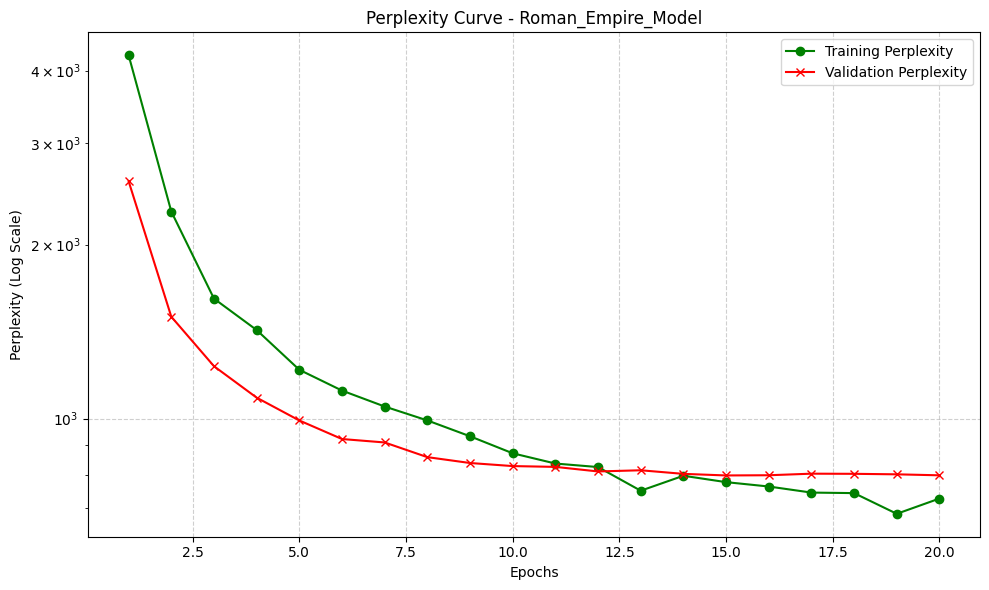

In [25]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.optim as optim
dataset = TensorDataset(input_ids, labels)


total_size = len(dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=16, shuffle=False)


learning_rate=1e-4
model_dim=256
n_head=8
num_layer=2
dropout=0.4
model = RomanEmbeddingModel(vocab_size=len(vocab), d_model=model_dim, nhead=n_head, num_layers=num_layer,seq_length=131, dropout=dropout).to(device)
optimizer = optim.Adam(model.parameters(), lr = learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.LinearLR(optimizer)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

train_perplexity_hist = []
valid_perplexity_hist = []

EPOCHS = 20
for epoch_idx in range(EPOCHS):
      print("-----------------------------------")
      print("Epoch %d" % (epoch_idx+1))
      print("-----------------------------------")

      train_loss, avg_train_loss = train(model, train_loader, optimizer, criterion, device=device)


      val_loss, avg_val_loss = evaluate(model, val_loader, criterion, device=device)

      scheduler.step(avg_val_loss)


      print("Training Loss: %.4f. Validation Loss: %.4f. " % (avg_train_loss, avg_val_loss))
      print("Training Perplexity: %.4f. Validation Perplexity: %.4f. " % (np.exp(avg_train_loss), np.exp(avg_val_loss)))
      train_perplexity_hist.append(np.exp(avg_train_loss))
      valid_perplexity_hist.append(np.exp(avg_val_loss))

plot_curves(train_perplexity_hist, valid_perplexity_hist, "Roman_Empire_Model")

## Extract the embedding

In [26]:
model.eval()
all_node_features = []

with torch.no_grad():
    x = model.embed(padded_inputs.to(device)) + model.pos_embed
    output = model.Transformer(x)

for i, sent in enumerate(sentences):
    actual_length_sent = len(sent)
    embeddings = output[i, :actual_length_sent, :]
    all_node_features.append(embeddings.cpu())

node_features = torch.cat(all_node_features, dim=0).numpy()

print(f"Final Graph Node features: {node_features.shape}")

Final Graph Node features: (22600, 256)


## Extract to CSV

In [34]:
print(f"Total words in valid_tokens: {len(valid_tokens)}")
print(f"Total rows in node_features: {len(node_features)}")
print(f"Embedding size: {node_features.shape[1]} ")


Total words in valid_tokens: 22600
Total rows in node_features: 22600
Embedding size: 256 


In [35]:
embeddings_df = pd.DataFrame(node_features)
embeddings_df.to_csv('../data/node_features.csv', index=False, header=False)

# BERT Autotransformer

In [33]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased").to(device)
model.eval()

all_node_features = []

#sentences is already filtered from punctuations and spaces
for sent in sentences:
    raw_words = [t.text for t in sent]

    encoding = tokenizer(raw_words, 
                         is_split_into_words=True, 
                         return_tensors="pt", 
                         truncation=True, 
                         max_length=512).to(device)
    
    with torch.no_grad():
        outputs = model(**encoding)
        last_hidden_state = outputs.last_hidden_state.squeeze(0)

    word_ids = encoding.word_ids()
    word_embeddings = []
    prev_word_idx = None
    temp_subwords = []

    for i, word_idx in enumerate(word_ids):
            if word_idx is None: continue # Skip [CLS] and [SEP]
            
            if word_idx != prev_word_idx:
                # New word starts: average the previous subword vectors
                if temp_subwords:
                    word_embeddings.append(torch.stack(temp_subwords).mean(dim=0))
                    temp_subwords = []
            
            temp_subwords.append(last_hidden_state[i])
            prev_word_idx = word_idx
        
    # Add the last word
    if temp_subwords:
        word_embeddings.append(torch.stack(temp_subwords).mean(dim=0))

    # word_embeddings now has exactly len(sent) vectors!
    all_node_features.extend(word_embeddings)

# Convert to the final matrix for your GNN
node_features_matrix = torch.stack(all_node_features).cpu().numpy()
print(node_features_matrix.shape) # (22600, 768)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 10270.04it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(22600, 768)


## Extract to CSV   

In [36]:
print(f"Total words in valid_tokens: {len(valid_tokens)}")
print(f"Total rows in node_features: {len(node_features_matrix)}")
print(f"Embedding size: {node_features_matrix.shape[1]} ")


Total words in valid_tokens: 22600
Total rows in node_features: 22600
Embedding size: 768 


In [39]:
embeddings_df = pd.DataFrame(node_features_matrix)
embeddings_df.to_csv('../data/node_features.csv', index=False, header=False)

# RoBERTa

In [42]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained("roberta-base")
model = AutoModel.from_pretrained("roberta-base").to(device)
model.eval()

all_node_features = []

#sentences is already filtered from punctuations and spaces
for sent in sentences:
    raw_words = [t.text for t in sent]

    encoding = tokenizer(raw_words, 
                         is_split_into_words=True, 
                         return_tensors="pt", 
                         truncation=True, 
                         max_length=512).to(device)
    
    with torch.no_grad():
        outputs = model(**encoding)
        last_hidden_state = outputs.last_hidden_state.squeeze(0)

    word_ids = encoding.word_ids()
    word_embeddings = []
    prev_word_idx = None
    temp_subwords = []

    for i, word_idx in enumerate(word_ids):
            if word_idx is None: continue # Skip [CLS] and [SEP]
            
            if word_idx != prev_word_idx:
                # New word starts: average the previous subword vectors
                if temp_subwords:
                    word_embeddings.append(torch.stack(temp_subwords).mean(dim=0))
                    temp_subwords = []
            
            temp_subwords.append(last_hidden_state[i])
            prev_word_idx = word_idx
        
    # Add the last word
    if temp_subwords:
        word_embeddings.append(torch.stack(temp_subwords).mean(dim=0))

    # word_embeddings now has exactly len(sent) vectors!
    all_node_features.extend(word_embeddings)

# Convert to the final matrix for your GNN
node_features_matrix = torch.stack(all_node_features).cpu().numpy()
print(node_features_matrix.shape) # (22600, 768)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 12562.38it/s]
RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


(22600, 768)


## Extract to CSV

In [43]:
print(f"Total words in valid_tokens: {len(valid_tokens)}")
print(f"Total rows in node_features: {len(node_features_matrix)}")
print(f"Embedding size: {node_features_matrix.shape[1]} ")


Total words in valid_tokens: 22600
Total rows in node_features: 22600
Embedding size: 768 


In [44]:
embeddings_df = pd.DataFrame(node_features_matrix)
embeddings_df.to_csv('../data/node_features.csv', index=False, header=False)

## Identify the Node Class

In [61]:
from collections import Counter

# Get all raw syntactic roles from your valid_tokens list
raw_roles = [token.dep_ for token in valid_tokens]

role_counts = Counter(raw_roles)

# Identify the 17 most frequent roles
top_17_roles = [role for role, count in role_counts.most_common(17)]

for i, role in enumerate(top_17_roles):
    print(f"Class {i}: {role} ({role_counts[role]} occurrences)")

Class 0: pobj (3162 occurrences)
Class 1: prep (3137 occurrences)
Class 2: det (2510 occurrences)
Class 3: amod (2376 occurrences)
Class 4: conj (1383 occurrences)
Class 5: nsubj (1224 occurrences)
Class 6: cc (1080 occurrences)
Class 7: compound (928 occurrences)
Class 8: ROOT (923 occurrences)
Class 9: dobj (872 occurrences)
Class 10: advmod (795 occurrences)
Class 11: aux (446 occurrences)
Class 12: auxpass (370 occurrences)
Class 13: appos (362 occurrences)
Class 14: nsubjpass (329 occurrences)
Class 15: poss (321 occurrences)
Class 16: relcl (296 occurrences)


In [62]:
number_roles = [t.dep_ for t in valid_tokens if t.like_num]
num_role_counts = Counter(number_roles)

print("Roles assigned to numbers:")
for role, count in num_role_counts.items():
    print(f"{role}: {count}")

Roles assigned to numbers:
amod: 91
nummod: 183
pobj: 39
compound: 20
attr: 13
quantmod: 11
conj: 15
nsubjpass: 1
ccomp: 1
dobj: 4
appos: 8
poss: 3
advmod: 3
nsubj: 2
oprd: 1
npadvmod: 1
prep: 1


In [63]:
role_to_class = {role: i for i, role in enumerate(top_17_roles)}

node_labels = []
for role in raw_roles:
    # Get class ID from mapping, default to 17 (18th class) if not in top 17
    class_id = role_to_class.get(role, 17)
    node_labels.append(class_id)

import numpy as np
y = np.array(node_labels)

print(f"\nNode labels shape: {y.shape}")
print(f"Unique classes found: {np.unique(y)}")


Node labels shape: (22600,)
Unique classes found: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]


# Generate the Edge Index

In [64]:
edges = list(G.edges())
edge_list_df = pd.DataFrame(edges, columns=['source', 'target'])
edge_list_df = edge_list_df.astype(int)
edge_list_df.to_csv('../data/edge_list.txt', sep=' ', index=False, header=False)


# Create Labels

In [65]:
import pandas as pd
import numpy as np

labels_df = pd.Series(y)

# Save to labels.csv
labels_df.to_csv('../data/labels.csv', index=False, header=False)


# Generate NPZ

In [46]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from scripts.create_npz import create_npx

create_npx.create_npz_dataset(node_features_file="../data/node_features.csv", labels_file='../data/labels.csv', edges_file='../data/edge_list.txt', num_splits=10, output_file_name='../data/roman-RoBERTA.npz')


Verified Split 0 - Train: 13560, Val: 4520, Test: 4520
no of nodes 22600
no of features per node 768
no of node labels, should matach no of nodes 22600
no of edges 32684
